In [1]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # Only errors are logged
os.environ['TF_GPU_ALLOCATOR'] ='cuda_malloc_async'

import numpy as np
import keras
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers
from keras import ops

# TF imports related to tf.data preprocessing
from tensorflow import data as tf_data
from tensorflow import image as tf_image
from tensorflow.keras.utils import plot_model

keras.utils.set_random_seed(42)
from sklearn.model_selection import train_test_split

I0000 00:00:1777486667.958773  900284 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777486669.553101  900284 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
BATCH_SIZE = 32
NUM_CLASSES = 4
EPOCHS = 500
SAMPLE_RATE = 16000
OUT_SEQ_LEN = 72000

In [3]:
keras.backend.clear_session(free_memory=True)
train_ds =tf.keras.utils.image_dataset_from_directory(directory='dataset_stft_img_ar/train',
image_size=(300, 300),
batch_size=BATCH_SIZE)
val_ds =tf.keras.utils.image_dataset_from_directory(directory='dataset_stft_img_ar/val',
image_size=(300, 300),
batch_size=BATCH_SIZE)
test_ds =tf.keras.utils.image_dataset_from_directory(directory='dataset_stft_img_ar/test',
image_size=(300, 300),
batch_size=BATCH_SIZE)

Found 880 files belonging to 4 classes.
Found 75 files belonging to 4 classes.
Found 75 files belonging to 4 classes.


In [4]:
model_ar = keras.models.load_model('stft_model.keras')

In [5]:
model_ar.layers

[<Rescaling name=rescaling, built=True>,
 <Functional name=inception_v3, built=True>,
 <GlobalAveragePooling2D name=global_average_pooling2d, built=True>,
 <BatchNormalization name=batch_normalization_94, built=True>,
 <Dense name=dense, built=True>,
 <Dropout name=dropout, built=True>,
 <Dense name=output, built=True>]

In [6]:
model_ar.pop()

<Dense name=output, built=True>

In [7]:
model_ar.add(layers.Dense((NUM_CLASSES),activation = 'softmax',name='output'))

In [8]:
model_ar.trainable=True
model_ar.layers[4].trainable=True
model_ar.layers[6].trainable=True

In [9]:
model_ar.summary()
keras.backend.clear_session(free_memory=True)
model_ar.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-5,weight_decay=1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_94          │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,479,286 (101.01 MB)

 Trainable params: 2,202,244 (8.40 MB)

 Non-trainable params: 19,871,520 (75.80 MB)

 Optimizer params: 4,405,522 (16.81 MB)

In [11]:
history_ar = model_ar.fit(train_ds,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
          validation_data=val_ds,
        callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
        )]        )

Epoch 1/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 19s 365ms/step - loss: 2.1608 - sparse_categorical_accuracy: 0.2420 - val_loss: 1.8879 - val_sparse_categorical_accuracy: 0.2533
Epoch 2/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 1.7804 - sparse_categorical_accuracy: 0.3761 - val_loss: 1.6831 - val_sparse_categorical_accuracy: 0.3200
Epoch 3/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 1.5780 - sparse_categorical_accuracy: 0.3966 - val_loss: 1.5475 - val_sparse_categorical_accuracy: 0.3333
Epoch 4/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 1.4553 - sparse_categorical_accuracy: 0.4705 - val_loss: 1.4688 - val_sparse_categorical_accuracy: 0.4133
Epoch 5/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 1.3180 - sparse_categorical_accuracy: 0.5125 - val_loss: 1.4239 - val_sparse_categorical_accuracy: 0.4667
Epoch 6/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 1.2913 - sparse_categorical_accuracy: 0.5034 - val_loss: 1.4000 - val_sparse_categorical_accuracy: 0.4800
Ep

In [12]:
model_ar.evaluate(test_ds)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.3565 - sparse_categorical_accuracy: 0.5200


[1.3564661741256714, 0.5199999809265137]

Classification Report:
              precision    recall  f1-score   support

       angry       0.83      0.75      0.79        20
       happy       0.50      0.12      0.19        17
     neutral       0.35      0.63      0.45        19
         sad       0.53      0.53      0.53        19

    accuracy                           0.52        75
   macro avg       0.55      0.51      0.49        75
weighted avg       0.56      0.52      0.50        75



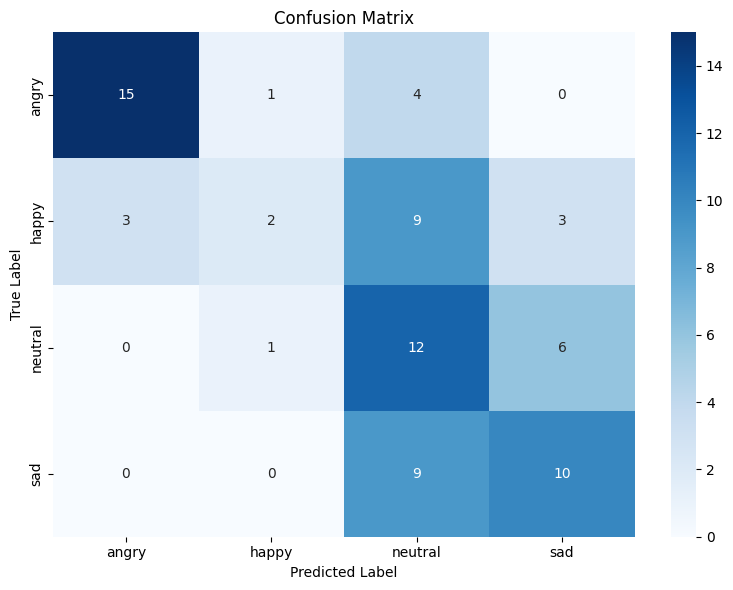

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix


true_labels = []
predicted_labels = []

for images, labels in test_ds:
    # Get model predictions (probabilities)
    preds = model_ar.predict(images, verbose=0)
    
    # Convert to class indices
    pred_classes = np.argmax(preds, axis=1)
    
    true_labels.extend(labels.numpy())
    predicted_labels.extend(pred_classes)

true_labels      = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

class_names = test_ds.class_names 


print("Classification Report:")
print(classification_report(true_labels, predicted_labels, target_names=class_names))


cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()